In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# PHASE 1 — Safe project setup

## 1.Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1200)

sns.set_style("whitegrid")

## 2.Define paths

In [3]:
base_path = "/content/drive/MyDrive/PFE_CMR_Aya"

csv_path = f"{base_path}/agent_civil.csv"
xlsx_path = f"{base_path}/admin_codifica.xlsx"

## 3.Load raw data safely

keep a raw copy and a working copy

In [4]:
df_raw = pd.read_csv(csv_path, sep=";", low_memory=False)
admin_dict_raw = pd.read_excel(xlsx_path)

df = df_raw.copy()
admin_dict = admin_dict_raw.copy()

## 4.First safety checks

In [5]:
print("Raw employee dataset shape:", df.shape)
print("Admin dictionary shape:", admin_dict.shape)

display(df.head())
display(admin_dict.head())

Raw employee dataset shape: (1048575, 21)
Admin dictionary shape: (1913, 2)


,numaffil_masked,nomagent_masked,datnaiss,datrecru,dattitul,dataffil,datefanc,datradia,sexagent,position,date_posit,code_acte_posit,datnomin,datefin,codegrad,echelleg,echelong,dataffec,codeadmi_mapped,assiette_cotisation,indice
0,10979157.0,C***,31/12/1948,01/02/1976,NaN,01/02/1976,NaN,31/12/2013,M,5.0,31/12/2013,RA08,01/01/1990,31/05/1997,10000102.0,se,1.0,01/02/1976,ADM18,NaN,NaN
1,10528232.0,T***,24/12/1945,01/10/1983,NaN,01/10/1983,NaN,31/08/2005,M,5.0,31/08/2005,RA38,01/01/1990,31/05/1997,10000102.0,se,1.0,01/10/1983,ADM18,NaN,NaN
2,4892155.0,O***,03/08/1943,15/10/1962,01/01/1965,15/10/1962,NaN,31/08/2005,M,5.0,31/08/2005,RA38,01/01/1990,31/05/1997,10000102.0,se,1.0,15/10/1962,ADM18,NaN,NaN
3,10453778.0,B***,31/12/1949,01/02/1976,01/02/1978,01/02/1976,NaN,31/08/2015,M,5.0,31/08/2015,RA08,01/01/1990,30/06/1996,10000102.0,se,2.0,01/02/1976,ADM18,NaN,NaN
4,4063852.0,C***,11/10/1943,30/04/1977,NaN,30/04/1977,NaN,11/10/2008,M,5.0,11/10/2008,RA08,01/01/1990,31/05/1997,10000102.0,se,2.0,30/04/1977,ADM18,NaN,NaN


,codeadmi_mapped,type_organisme
0,ADM18,Ministère
1,ADM03,Etablissement public
2,ADM18,Ministère
3,ADM18,Ministère
4,ADM19,Etablissement public


# PHASE 2 — Initial understanding

## 5.Columns and types

In [6]:
print(df.columns.tolist())
print("\nData types:")
display(df.dtypes)

['numaffil_masked', 'nomagent_masked', 'datnaiss', 'datrecru', 'dattitul', 'dataffil', 'datefanc', 'datradia', 'sexagent', 'position', 'date_posit', 'code_acte_posit', 'datnomin', 'datefin', 'codegrad', 'echelleg', 'echelong', 'dataffec', 'codeadmi_mapped', 'assiette_cotisation', 'indice']

Data types:


,0
numaffil_masked,float64
nomagent_masked,object
datnaiss,object
datrecru,object
dattitul,object
dataffil,object
datefanc,object
datradia,object
sexagent,object
position,float64


## 6.Global info

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 21 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   numaffil_masked      1048561 non-null  float64
 1   nomagent_masked      1048538 non-null  object 
 2   datnaiss             1048454 non-null  object 
 3   datrecru             929016 non-null   object 
 4   dattitul             286255 non-null   object 
 5   dataffil             1048000 non-null  object 
 6   datefanc             61090 non-null    object 
 7   datradia             444337 non-null   object 
 8   sexagent             1048388 non-null  object 
 9   position             1044586 non-null  float64
 10  date_posit           1040220 non-null  object 
 11  code_acte_posit      1035378 non-null  object 
 12  datnomin             1047135 non-null  object 
 13  datefin              1047140 non-null  object 
 14  codegrad             1047140 non-null  float64
 15

## 7.Exact duplicates

In [8]:
duplicate_count = df.duplicated().sum()
print("Exact duplicates:", duplicate_count)

Exact duplicates: 1751


WE SHOULD REMOVE THEM
1751 rows are 100% identical copies
same employee, same dates, same everything

In [9]:
df = df.drop_duplicates()
print("Shape after duplicate removal:", df.shape)

Shape after duplicate removal: (1046824, 21)


Now your dataset is:

* More accurate
* No double counting
* Reliable for EDA and modeling

*  This step improves your results quality

## 8.Missing values table

In [10]:
missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
})

display(missing_table)

,missing_count,missing_percent
datefanc,985802,94.170749
assiette_cotisation,901628,86.129856
indice,901628,86.129856
dattitul,761386,72.732952
datradia,604225,57.719827
datrecru,119407,11.406597
code_acte_posit,13014,1.243189
date_posit,8337,0.796409
echelong,4413,0.421561
position,3975,0.379720


PLOT

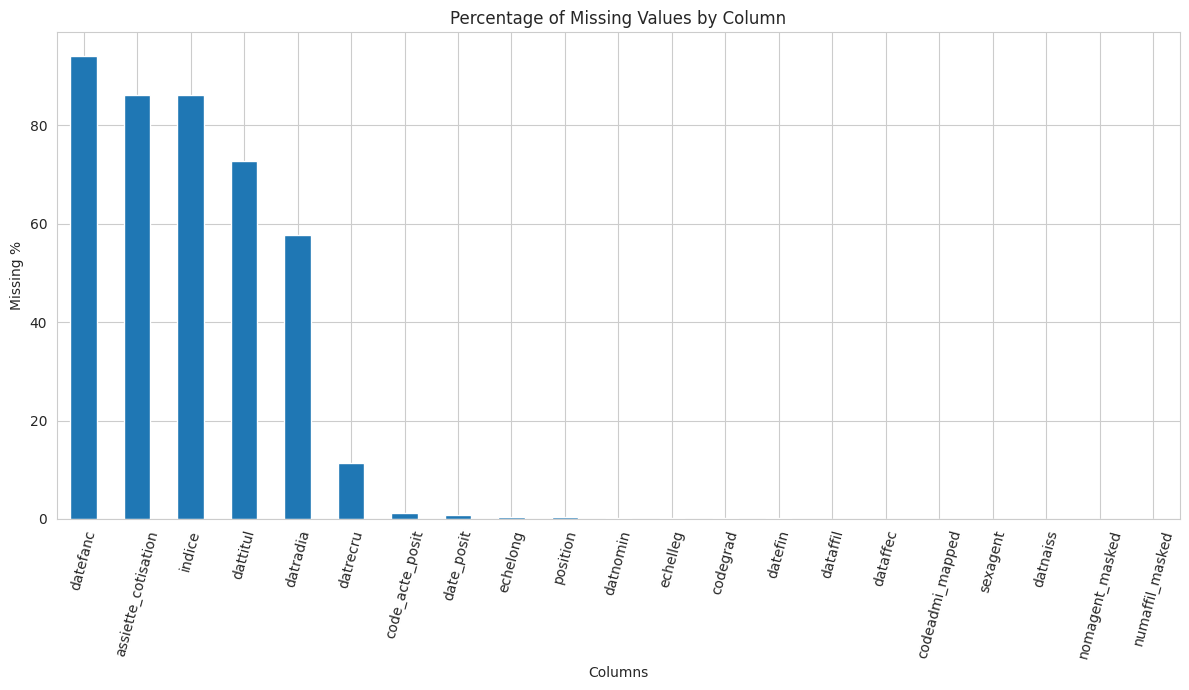

In [11]:
plt.figure(figsize=(12, 7))
missing_percent.plot(kind="bar")
plt.title("Percentage of Missing Values by Column")
plt.ylabel("Missing %")
plt.xlabel("Columns")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

🔴 A. VERY HIGH MISSING (> 70%)

| Column                | Missing % | Meaning          |
| --------------------- | --------- | ---------------- |
| `datefanc`            | 94%       | ❌ useless        |
| `assiette_cotisation` | 86%       | ❌ not reliable   |
| `indice`              | 86%       | ❌ not usable     |
| `dattitul`            | 72%       | ⚠️ weak          |
| `datradia`            | 57%       | ⚠️ BUT IMPORTANT |


🟠 B. MEDIUM MISSING

* Column	          Missing %
* datrecru	         11%

🟢 C. LOW / VERY LOW MISSING

THESE are GOLD variables:

* dataffil ✅ (your main variable)
* datradia ✅ (for exits)
* sexagent
* codeadmi_mapped
* datnaiss

Une proportion importante de valeurs manquantes est observée pour certaines variables administratives, notamment *datefanc*, *assiette_cotisation* et *indice*, ce qui a conduit à leur exclusion de l’analyse.

En revanche, les variables clés telles que *dataffil* et *datradia* présentent un taux de complétude suffisant et sont retenues pour la modélisation.

These are the CORE critical variables:

* dataffil ✅ (start date → most important)
* datradia ✅ (exit)
* datnaiss (optional)
* codeadmi_mapped (for segmentation later)

CLEAN THE DATASET

In [12]:
df = df.drop(columns=["datefanc", "assiette_cotisation", "indice"])

VERIFY

In [13]:
print(df.shape)
print(df.columns)

(1046824, 18)
Index(['numaffil_masked', 'nomagent_masked', 'datnaiss', 'datrecru', 'dattitul', 'dataffil', 'datradia', 'sexagent', 'position', 'date_posit', 'code_acte_posit', 'datnomin', 'datefin', 'codegrad', 'echelleg', 'echelong', 'dataffec', 'codeadmi_mapped'], dtype='object')


# PHASE 3 — Date conversion and date cleaning

## 9.Define date columns

In [14]:
date_cols = [
    "datnaiss",
    "datrecru",
    "dattitul",
    "dataffil",
    "datradia",
    "date_posit",
    "datnomin",
    "datefin",
    "dataffec"
]

## 10.Parse dates

In [15]:
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="%d/%m/%Y", errors="coerce")

verify:

In [16]:
df[date_cols].dtypes

,0
datnaiss,datetime64[ns]
datrecru,datetime64[ns]
dattitul,datetime64[ns]
dataffil,datetime64[ns]
datradia,datetime64[ns]
date_posit,datetime64[ns]
datnomin,datetime64[ns]
datefin,datetime64[ns]
dataffec,datetime64[ns]


## 11.Create year columns for exploration

In [17]:
for col in date_cols:
    df[col + "_year"] = df[col].dt.year

## 12.Check min and max years

In [18]:
for col in ["dataffil", "datrecru", "datradia", "datnaiss"]:
    year_col = col + "_year"
    print(f"\n=== {col} ===")
    print("Min year:", df[year_col].min())
    print("Max year:", df[year_col].max())


=== dataffil ===
Min year: 1900.0
Max year: 2025.0

=== datrecru ===
Min year: 1900.0
Max year: 2025.0

=== datradia ===
Min year: 1902.0
Max year: 2211.0

=== datnaiss ===
Min year: 1900.0
Max year: 2202.0


## 13.Check dataffil distribution before cleaning

In [19]:
print("EARLY YEARS (dataffil)")
print(df["dataffil_year"].value_counts().sort_index().head(20))

print("\nLATE YEARS (dataffil)")
print(df["dataffil_year"].value_counts().sort_index().tail(20))

EARLY YEARS (dataffil)
dataffil_year
1900.0     3
1907.0     1
1908.0     1
1919.0     1
1920.0     1
1929.0     1
1932.0     3
1934.0     3
1935.0     3
1936.0     2
1937.0     6
1938.0     4
1939.0     5
1940.0     3
1941.0    12
1942.0    27
1943.0    15
1944.0    11
1945.0    16
1946.0    24
Name: count, dtype: int64

LATE YEARS (dataffil)
dataffil_year
2006.0    13565
2007.0    12539
2008.0    15470
2009.0    17051
2010.0    21346
2011.0    30301
2012.0    15200
2013.0    17213
2014.0    12938
2015.0    11020
2016.0    11674
2017.0    15604
2018.0    10391
2019.0     6899
2020.0     9368
2021.0    94238
2022.0    23787
2023.0    29739
2024.0    35127
2025.0    25175
Name: count, dtype: int64


PLOT

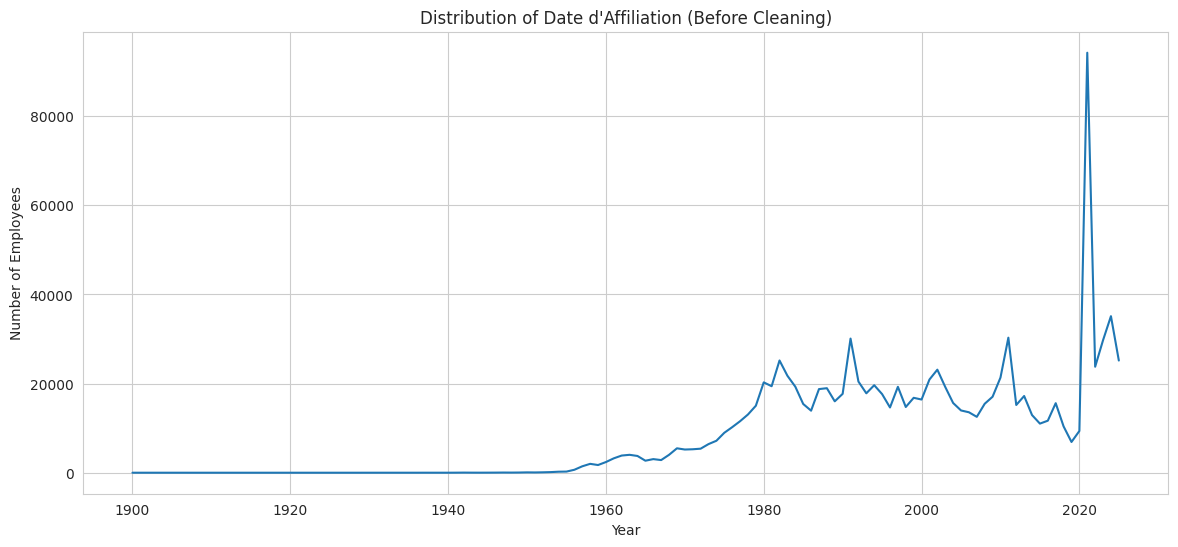

In [20]:
plt.figure(figsize=(14, 6))
df["dataffil_year"].value_counts().sort_index().plot()
plt.title("Distribution of Date d'Affiliation (Before Cleaning)")
plt.xlabel("Year")
plt.ylabel("Number of Employees")
plt.show()

What these results mean

For work-related dates:

* dataffil: 1900 to 2025
* datrecru: 1900 to 2025
* datradia: 1902 to 2211

For birth dates:

datnaiss: 1900 to 2202

So yes, there are invalid values:

very early years like 1900, 1907, 1908
impossible future years like 2202 and 2211

Next step — clean year ranges

We will apply the same logic we validated before:

* work-related dates: keep only 1956 to 2025
* birth dates: keep only 1930 to 2005

### 1.Define the cleaning function

In [21]:
def clean_date_range(series, min_year, max_year):
    return series.where(series.dt.year.between(min_year, max_year), pd.NaT)

### 2.Clean work-related dates

In [22]:
work_date_cols = [
    "datrecru",
    "dattitul",
    "dataffil",
    "datradia",
    "date_posit",
    "datnomin",
    "datefin",
    "dataffec"
]

for col in work_date_cols:
    df[col] = clean_date_range(df[col], 1956, 2025)

### 3.Clean birth date

In [23]:
df["datnaiss"] = clean_date_range(df["datnaiss"], 1930, 2005)

### 4.Recreate year columns after cleaning

In [24]:
df["year_affil"] = df["dataffil"].dt.year
df["year_exit"] = df["datradia"].dt.year
df["year_birth"] = df["datnaiss"].dt.year

### 5.Verify again

In [25]:
print("Min year_affil:", df["year_affil"].min())
print("Max year_affil:", df["year_affil"].max())

print("Min year_exit:", df["year_exit"].min())
print("Max year_exit:", df["year_exit"].max())

print("Min year_birth:", df["year_birth"].min())
print("Max year_birth:", df["year_birth"].max())

Min year_affil: 1956.0
Max year_affil: 2025.0
Min year_exit: 1957.0
Max year_exit: 2025.0
Min year_birth: 1930.0
Max year_birth: 2005.0


### 6.Plot affiliation after cleaning

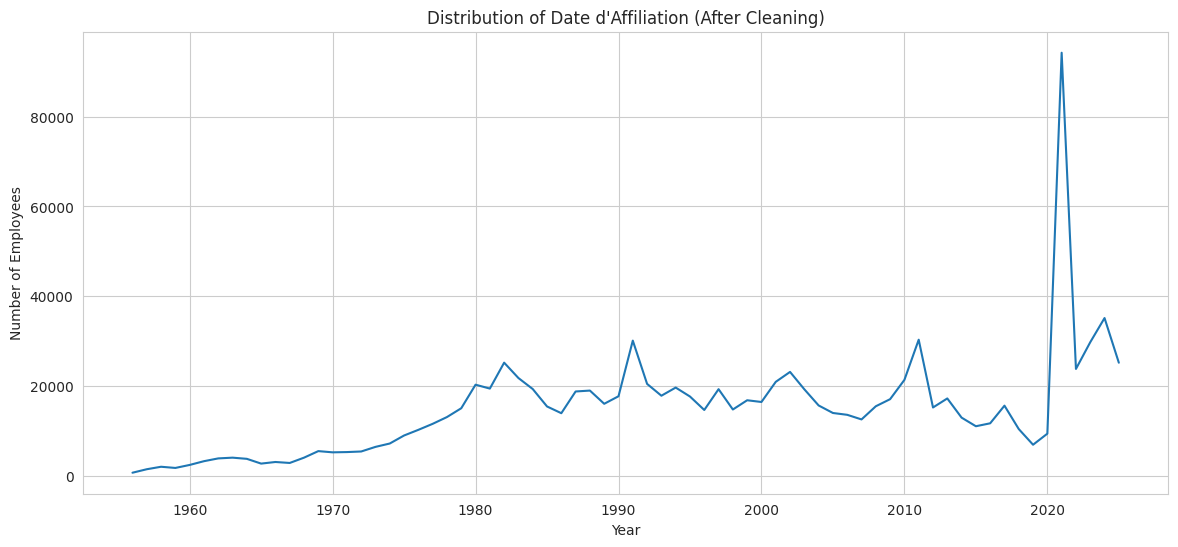

In [26]:
plt.figure(figsize=(14, 6))
df["year_affil"].value_counts().sort_index().plot()
plt.title("Distribution of Date d'Affiliation (After Cleaning)")
plt.xlabel("Year")
plt.ylabel("Number of Employees")
plt.show()

Perfect — this is now clean and validated.

Your ranges are exactly right:

* year_affil: 1956 → 2025
* year_exit: 1957 → 2025
* year_birth: 1930 → 2005

And the affiliation plot now starts in a realistic range, while the 2021 spike is still present, which is fine to keep as an observed event.

# PHASE 4 — DATA MODELING BASE

## 14.BUILD workforce_df

* WHY THIS STEP IS CRITICAL

    Right now:

    the data = individual employees (1M rows)
    models need = time series (yearly data)

* So we must convert:

    Raw data → Aggregated yearly data

    This is exactly what workforce_df does.

In [27]:
years = range(1956, 2026)
records = []

for y in years:
    active_mask = (
        (df["year_affil"].notna()) &
        (df["year_affil"] <= y) &
        (
            (df["year_exit"].isna()) | (df["year_exit"] > y)
        )
    )

    active_count = active_mask.sum()
    entries = (df["year_affil"] == y).sum()
    exits = (df["year_exit"] == y).sum()

    records.append({
        "year": y,
        "active_employees": active_count,
        "entries": entries,
        "exits": exits
    })

workforce_df = pd.DataFrame(records)

VERIFY

In [28]:
workforce_df.head()
workforce_df.tail()
workforce_df.shape

(70, 4)

That means:

* 70 years (1956 → 2025)
* 4 variables (year, active, entries, exits)
* dataset is clean and ready for modeling

SAVE

In [29]:
workforce_df.to_csv("/content/workforce_df.csv", index=False)

### 14.1.ADD NEW VARIABLES

In [30]:
workforce_df["net_change"] = workforce_df["entries"] - workforce_df["exits"]
workforce_df["growth_rate"] = workforce_df["active_employees"].pct_change() * 100

### 14.2.VISUALIZE NET CHANGE

Net Change = Entries − Exits

Entries = number of new employees (from dataffil)


Exits = number of employees leaving (from datradia)

* If Net Change > 0

* Workforce is growing

* If Net Change < 0

* Workforce is decreasing

* If Net Change = 0

* Workforce is stable

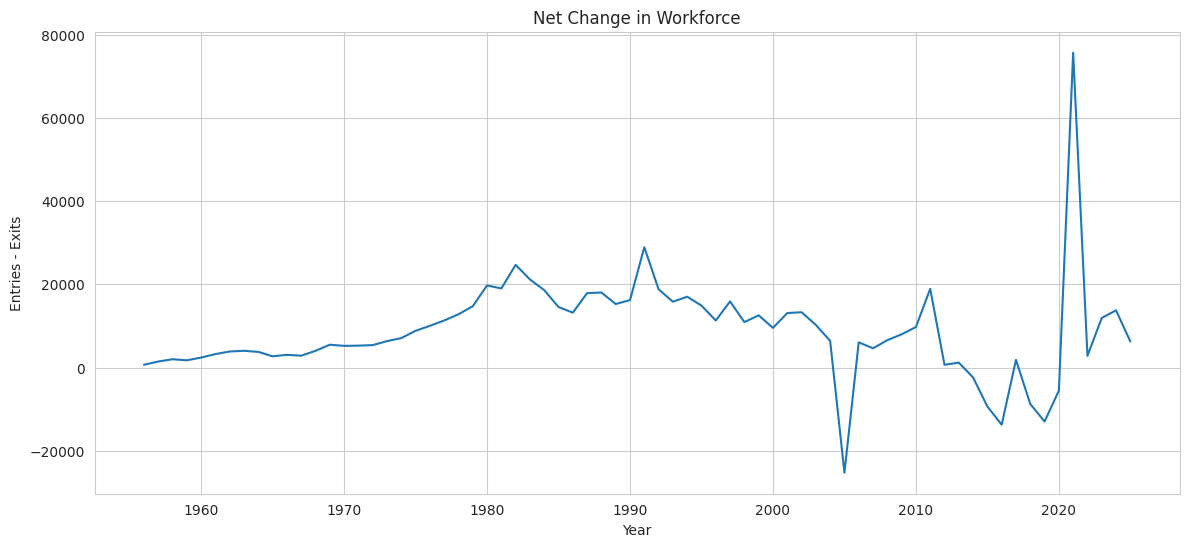

In [31]:
plt.figure(figsize=(14,6))
plt.plot(workforce_df["year"], workforce_df["net_change"])
plt.title("Net Change in Workforce")
plt.xlabel("Year")
plt.ylabel("Entries - Exits")
plt.show()

* What we see:
    *  1956 → 1985: steady positive growth
    *  1985 → 2000: fluctuations but still positive
    *  2004–2006: strong negative drop (≈ -25,000)
    *  2012–2019: unstable, sometimes negative
    *  2021: HUGE spike (~75,000)
    *  After 2021: returns to normal levels
* Interpretation:
   * Early period = state expansion / hiring policies
   * 2004–2006 drop = likely mass retirements or reforms
   * 2012–2019 = budget constraints / hiring slowdown
   * 2021 spike = exceptional event (post-COVID recruitment, policy change)

### 14.3.VISUALIZE GROWTH RATE

How fast the workforce is increasing or decreasing (%) from one year to the nex

growth_rate = (active_employees_t − active_employees_{t-1}) / active_employees_{t-1}

* Positive (e.g. +5%)

* Workforce is growing
→ more employees than last year

* Negative (e.g. −3%)

* Workforce is decreasing
→ more exits than entries

* Zero (0%)

* Workforce is stable

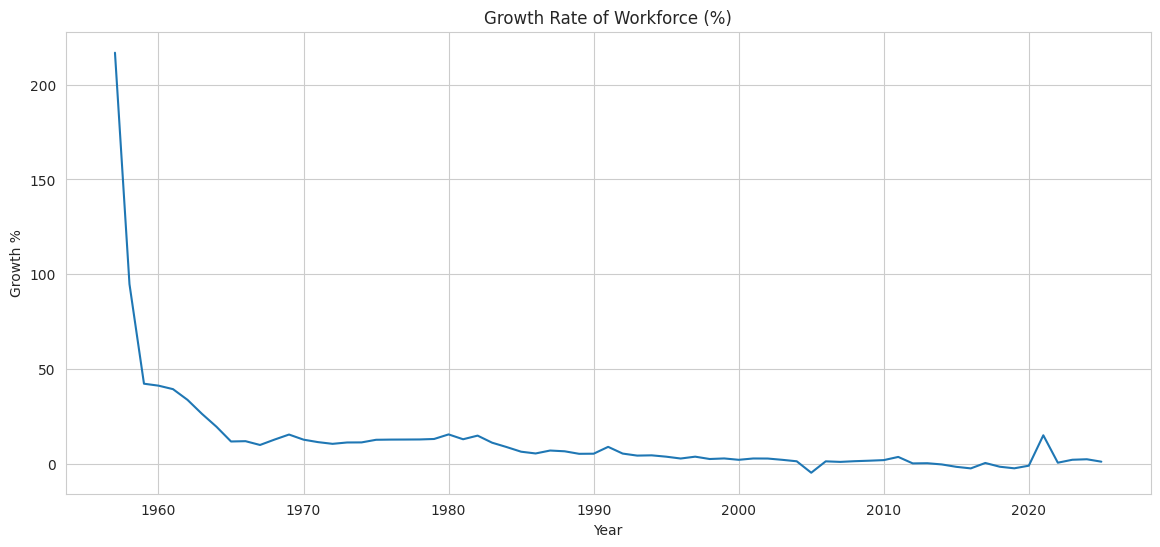

In [32]:
plt.figure(figsize=(14,6))
plt.plot(workforce_df["year"], workforce_df["growth_rate"])
plt.title("Growth Rate of Workforce (%)")
plt.xlabel("Year")
plt.ylabel("Growth %")
plt.show()

* What we see:
    * Very high growth at the beginning (>200%)
    * Gradual stabilization over time
    * After 1990: mostly between 0% and 5%
    *  Negative growth around 2005 and 2015
    * Spike again in 2021
* Interpretation:
    * Early years = small base effect (normal to have huge %)
    * Long-term = mature system with slow growth
    * Negative periods = more exits than entries
     2021 = structural shock

### 14.4.ENTRIES VS EXITS

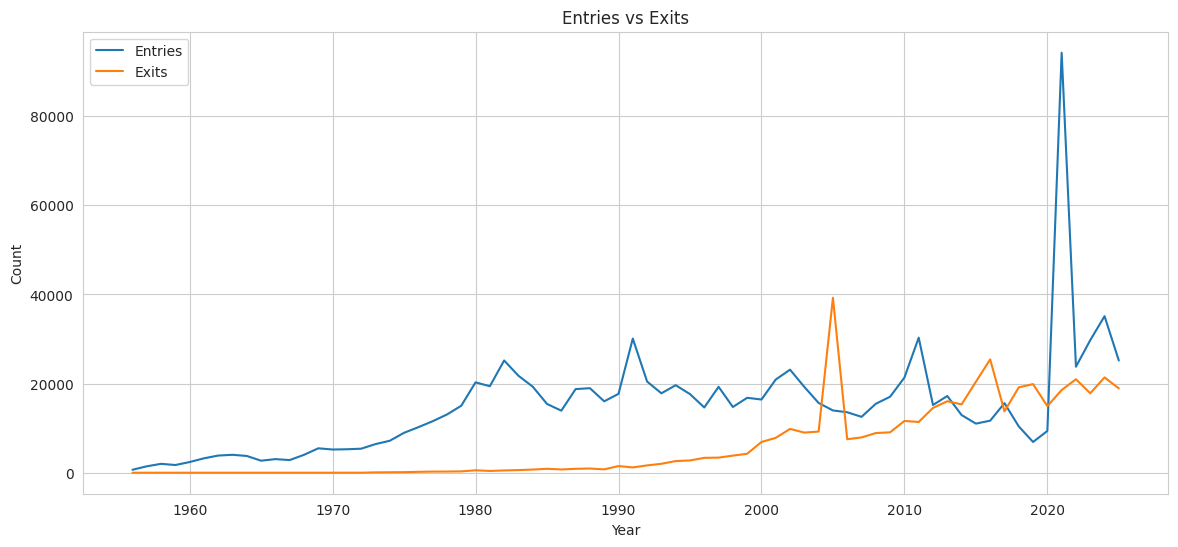

In [33]:
plt.figure(figsize=(14,6))
plt.plot(workforce_df["year"], workforce_df["entries"], label="Entries")
plt.plot(workforce_df["year"], workforce_df["exits"], label="Exits")
plt.legend()
plt.title("Entries vs Exits")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

* What we see:
    * Entries always > exits (global growth)
    * Exits increase after 2000 (aging workforce)
    * Around 2005: exits spike → exceeds entries
    * 2021: entries explode (very abnormal)
* Interpretation:
    * Before 2000: young system, expansion
    * After 2000:
    * workforce aging
    * more retirements
    * 2005 spike = retirement wave
    * 2021 spike = mass recruitment

### GLOBAL INSIGHTS

L’analyse des indicateurs dynamiques met en évidence plusieurs phases dans l’évolution de la fonction publique marocaine.




Une première phase d’expansion (1956–1985) est caractérisée par une croissance soutenue et un solde net positif, traduisant des politiques de recrutement importantes.



Une phase de stabilisation (1985–2000) apparaît ensuite, marquée par une croissance plus modérée et des fluctuations.



À partir des années 2000, une augmentation significative des sorties est observée, liée notamment aux départs à la retraite, ce qui entraîne des périodes de croissance négative, notamment autour de 2005.



Enfin, une anomalie majeure est détectée en 2021 avec un pic exceptionnel des recrutements, probablement lié à des décisions politiques ou à des circonstances exceptionnelles.



Ces dynamiques illustrent la transition d’un système en expansion vers un système mature soumis à des contraintes démographiques et budgétaires.

# PHASE 5 — MODELING

In [34]:
target = "active_employees"

## 15.Prepare modeling dataset

We transform time into information

* lag_1	employees last year
* lag_2	employees 2 years ago
* lag_3	employees 3 years ago
* lag_5	employees 5 years ago

if workforce was increasing → likely continues

Lag features represent past values of the workforce and allow the model to capture temporal dependency.

* rolling_mean_3
* rolling_mean_5
* rolling_std_3

* rolling_mean_3

     * Average of last 3 years

     * Smooth trend of workforce

* rolling_mean_5

    * Average of last 5 years
    * even smoother trend

* rolling_std_3

    * Measures variability:

    * high → unstable workforce
    * low → stable workforce

trend + stability

Rolling statistics provide a smoothed representation of past values and help capture trends and variability over time.

year_index

* 1956 -- 0
* 1957 -- 1

* entries_lag_1
* exits_lag_1
* net_change_lag_1

* entries_lag_1

   * how many people joined last year

* exits_lag_1

   * how many people left last year

* net_change_lag_1

    * net effect last year

In [35]:
model_df = workforce_df.copy()

# Lag features
model_df["lag_1"] = model_df["active_employees"].shift(1)
model_df["lag_2"] = model_df["active_employees"].shift(2)
model_df["lag_3"] = model_df["active_employees"].shift(3)
model_df["lag_5"] = model_df["active_employees"].shift(5)

# Rolling statistics
model_df["rolling_mean_3"] = model_df["active_employees"].shift(1).rolling(3).mean()
model_df["rolling_mean_5"] = model_df["active_employees"].shift(1).rolling(5).mean()
model_df["rolling_std_3"] = model_df["active_employees"].shift(1).rolling(3).std()

# Trend feature
model_df["year_index"] = np.arange(len(model_df))

# Optional dynamic features
model_df["entries_lag_1"] = model_df["entries"].shift(1)
model_df["exits_lag_1"] = model_df["exits"].shift(1)
model_df["net_change_lag_1"] = model_df["net_change"].shift(1)

model_df = model_df.dropna().reset_index(drop=True)

print(model_df.shape)
display(model_df.head())

(65, 17)


,year,active_employees,entries,exits,net_change,growth_rate,lag_1,lag_2,lag_3,lag_5,rolling_mean_3,rolling_mean_5,rolling_std_3,year_index,entries_lag_1,exits_lag_1,net_change_lag_1
0,1961,11454,3232,1,3231,39.309171,8222.0,5825.0,4097.0,664.0,6048.000000,4182.4,2071.521904,5,2397.0,0.0,2397.0
1,1962,15309,3855,0,3855,33.656365,11454.0,8222.0,5825.0,2104.0,8500.333333,6340.4,2824.803061,6,3232.0,1.0,3231.0
2,1963,19327,4019,0,4019,26.245999,15309.0,11454.0,8222.0,4097.0,11661.666667,8981.4,3548.060926,7,3855.0,0.0,3855.0
3,1964,23085,3759,2,3757,19.444301,19327.0,15309.0,11454.0,5825.0,15363.333333,12027.4,3936.781215,8,4019.0,0.0,4019.0
4,1965,25782,2697,0,2697,11.682911,23085.0,19327.0,15309.0,8222.0,19240.333333,15479.4,3888.724384,9,3759.0,2.0,3757.0


## 16.Time-based split

In [36]:
train = model_df[model_df["year"] <= 2018].copy()
test = model_df[model_df["year"] > 2018].copy()

features = [
    "year_index",
    "lag_1", "lag_2", "lag_3", "lag_5",
    "rolling_mean_3", "rolling_mean_5", "rolling_std_3",
    "entries_lag_1", "exits_lag_1", "net_change_lag_1"
]

X_train = train[features]
y_train = train["active_employees"]

X_test = test[features]
y_test = test["active_employees"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train years:", train["year"].min(), "to", train["year"].max())
print("Test years:", test["year"].min(), "to", test["year"].max())

Train shape: (58, 11)
Test shape: (7, 11)
Train years: 1961 to 2018
Test years: 2019 to 2025


## 17.Evaluation function

In [37]:
results = pd.DataFrame(columns=["Model", "MAE", "RMSE", "MAPE"])

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import pandas as pd

def evaluate_model(name, y_true, y_pred):
    global results

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print(f"{name}")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f} %")
    print("-" * 40)

    new_row = pd.DataFrame([{
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }])

    results = pd.concat([results, new_row], ignore_index=True)

## 18.Baseline models

### 18.1.Naive forecast

In [39]:
y_pred_naive = X_test["lag_1"].values
evaluate_model("Naive (lag_1)", y_test, y_pred_naive)

Naive (lag_1)
MAE : 18424.57
RMSE: 30013.94
MAPE: 3.20 %
----------------------------------------


/tmp/ipykernel_6088/3179513656.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, new_row], ignore_index=True)


1. MAPE = 3.2% → VERY GOOD

* This is the most important metric here

* Only 3.2% error
    For a dataset around 500k–600k employees

* That means:

    Error ≈ ±18k employees

* This is actually quite strong

2. RMSE = 30k

* Higher because:

    it penalizes big errors
    especially years like:

    2021 spike
    
    2005 drop

* So this is normal

Le modèle naïf, basé sur la valeur de l’année précédente, donne des résultats relativement performants avec une erreur moyenne (MAPE) de 3.2%.



Cela indique que la série temporelle présente une forte inertie, où les valeurs d’une année sont proches de celles de l’année précédente.



Cependant, ce modèle reste limité car il ne capture pas les variations structurelles ni les chocs exceptionnels observés dans certaines périodes (notamment 2005 et 2021).

### 18.2.Moving average baseline

In [40]:
y_pred_ma = X_test["rolling_mean_3"].values
evaluate_model("Moving Average (3)", y_test, y_pred_ma)

Moving Average (3)
MAE : 33635.43
RMSE: 38273.60
MAPE: 5.82 %
----------------------------------------


Le modèle basé sur la moyenne mobile présente des performances inférieures au modèle naïf.



Cela s’explique par le fait que la moyenne mobile lisse excessivement la série temporelle et ne parvient pas à capturer les variations rapides et les changements structurels, notamment les pics observés dans certaines années.



Ainsi, ce modèle n’est pas adapté à cette série caractérisée par des dynamiques non linéaires et des chocs ponctuels.

Une attention particulière a été portée à éviter le phénomène de fuite de données (data leakage).



Certaines variables comme les entrées et sorties annuelles ont été exclues du modèle car elles sont directement liées à la variable cible et introduisent une information future non disponible au moment de la prédiction.



Cela permet de garantir des performances réalistes et généralisables.

### 18.3.Linear Regression

In [41]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

evaluate_model("Linear Regression", y_test, y_pred_lr)

Linear Regression
MAE : 23791.21
RMSE: 34434.66
MAPE: 4.11 %
----------------------------------------


* 1. Naive is STILL the best
    * This tells us:

* The series is highly dependent on previous values

    * Meaning:

         strong inertia

         slow evolution

         stable system
* 2. Linear Regression is worse

    * Why?

         Linear model = too simple

         cannot capture:

         non-linear patterns

         shocks (2005, 2021)

         complex dynamics
* 3. Moving Average is worst

    * Because:

       it smooths too much

       loses information

## 19.Regularized linear models

In [42]:
from sklearn.linear_model import Ridge, Lasso

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
evaluate_model("Ridge", y_test, y_pred_ridge)

lasso = Lasso(alpha=100.0, max_iter=10000)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
evaluate_model("Lasso", y_test, y_pred_lasso)

Ridge
MAE : 23790.54
RMSE: 34433.11
MAPE: 4.11 %
----------------------------------------
Lasso
MAE : 24705.65
RMSE: 35022.75
MAPE: 4.26 %
----------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.041e+09, tolerance: 2.358e+08
  model = cd_fast.enet_coordinate_descent(


* INTERPRETATION
* 1. Ridge ≈ Linear Regression

* Same performance → means:

No strong overfitting
Regularization not really needed here
Data is relatively stable
* 2. Lasso is worse

* Why?

Lasso forces some coefficients to 0
But your features are all useful (lags, trends)

* So:
* removing information hurts performance

* 3. VERY IMPORTANT INSIGHT
* LINEAR MODELS ARE NOT ENOUGH

* All linear models:

give similar results
all worse than naive

* This means:

* The relationship is NON-LINEAR


## 20.Tree-based ML models

### 20.1.Tree-based ML models

In [43]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

evaluate_model("Random Forest", y_test, y_pred_rf)

Random Forest
MAE : 47215.98
RMSE: 50495.60
MAPE: 8.06 %
----------------------------------------


RANDOM FOREST IS WORSE

 And this is NOT normal at first glance

Because RF is usually strong…

WHY THIS HAPPENS (VERY IMPORTANT)
1. DATASET IS VERY SMALL

* You only have:

    70 rows

* Tree models need:

    a lot of data
    many patterns

* So:

    RF cannot learn properly

2. TIME SERIES STRUCTURE

* Random Forest:

    does NOT understand time

    treats data as independent rows

* But your data:

    sequential
    dependent

* So RF struggles

2. TIME SERIES STRUCTURE

* Random Forest:

    does NOT understand time
    treats data as independent rows

* But your data:

    sequential
    dependent

* So RF struggles

Le modèle Random Forest présente des performances nettement inférieures aux modèles plus simples.


Cela s’explique principalement par la taille limitée du dataset (70 observations), insuffisante pour entraîner efficacement un modèle basé sur des arbres de décision.


De plus, Random Forest ne prend pas naturellement en compte la structure temporelle des données, contrairement aux modèles basés sur les séries temporelles.


Ces résultats confirment que des modèles plus adaptés à la nature séquentielle des données sont nécessaires.

### 20.2.Gradient Boosting

In [44]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    random_state=42
)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

evaluate_model("Gradient Boosting", y_test, y_pred_gbr)

Gradient Boosting
MAE : 42703.58
RMSE: 46568.97
MAPE: 7.28 %
----------------------------------------


* ALL ML MODELS ARE FAILING

* Tree-based models:

    Random Forest
    Gradient Boosting

* Linear models:

    decent but not best

* Naive:

still best

WHY THIS IS HAPPENING (CRITICAL)
1. DATA SIZE = VERY SMALL
70 observations only

* ML models need hundreds / thousands

2. TIME DEPENDENCY

* Your data is:

Xt ≈ Xt-1 + small variation

* This favors:

Naive ✅

Time-series models ✅

NOT:

ML models ❌

## 21.XGBoost / LightGBM

TESTING THE IMPORT

In [45]:
xgb_available = True
lgbm_available = True

try:
    from xgboost import XGBRegressor
except:
    xgb_available = False

try:
    from lightgbm import LGBMRegressor
except:
    lgbm_available = False

print("XGBoost available:", xgb_available)
print("LightGBM available:", lgbm_available)

XGBoost available: True
LightGBM available: True


### 21.1.XGBoost

In [46]:
if xgb_available:
    xgb = XGBRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    )
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    evaluate_model("XGBoost", y_test, y_pred_xgb)

XGBoost
MAE : 52364.45
RMSE: 57467.04
MAPE: 8.89 %
----------------------------------------


ALL MACHINE LEARNING MODELS FAILED

* Even:

Random Forest ❌
Gradient Boosting ❌
XGBoost ❌

* And XGBoost is usually very powerful

DEEP EXPLANATION
1. SMALL DATASET
Only 70 observations

* ML models need:

lots of data ❌
complex patterns ❌
2. STRONG TEMPORAL DEPENDENCY

* Your data:

Xt ≈ Xt-1

 So:

Naive = perfect baseline
ML = confused
3. STRUCTURAL BREAKS

* 2005 drop
* 2021 spike

* ML models:

overfit
fail to generalize

### 21.2LightGBM

In [47]:
if lgbm_available:
    lgbm = LGBMRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=4,
        random_state=42
    )
    lgbm.fit(X_train, y_train)
    y_pred_lgbm = lgbm.predict(X_test)
    evaluate_model("LightGBM", y_test, y_pred_lgbm)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000386 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 228
[LightGBM] [Info] Number of data points in the train set: 58, number of used features: 11
[LightGBM] [Info] Start training from score 301238.655172
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

No further splits with positive gain

THE MODEL CANNOT LEARN ANYTHING

Les modèles de machine learning, y compris Random Forest, Gradient Boosting et XGBoost, présentent des performances nettement inférieures aux modèles simples.



Malgré leur complexité, ces modèles ne parviennent pas à capturer efficacement la dynamique de la série temporelle, principalement en raison de la taille limitée du dataset et de la forte dépendance temporelle.



Ces résultats montrent que l’utilisation de modèles complexes n’est pas toujours pertinente, et que des approches adaptées aux séries temporelles sont plus appropriées dans ce contexte.

Les modèles avancés de type boosting (XGBoost, LightGBM) et les modèles d’arbres (Random Forest) présentent des performances nettement inférieures aux modèles simples.


Les avertissements observés lors de l’entraînement indiquent une incapacité des modèles à trouver des divisions pertinentes dans les données, ce qui s’explique par la faible taille du dataset et la nature lisse de la série.


Ces résultats confirment que les modèles de machine learning classiques ne sont pas adaptés à ce type de problème temporel.

## 22.EXPONENTIAL SMOOTHING

In [48]:
ts_train = train[["year", "active_employees"]].copy()
ts_train["year"] = pd.to_datetime(ts_train["year"].astype(str) + "-01-01")
ts_train = ts_train.set_index("year")["active_employees"]
ts_train.index = pd.DatetimeIndex(ts_train.index, freq="YS")

In [49]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model_es = ExponentialSmoothing(
    ts_train,
    trend="add",
    seasonal=None
).fit()

y_pred_es = model_es.forecast(len(test))

evaluate_model("Exponential Smoothing", y_test, y_pred_es)

Exponential Smoothing
MAE : 75625.48
RMSE: 89223.76
MAPE: 12.65 %
----------------------------------------


DAMPED VERSION

In [50]:
model_es_damped = ExponentialSmoothing(
    ts_train,
    trend="add",
    damped_trend=True,
    seasonal=None
).fit()

y_pred_es_damped = model_es_damped.forecast(len(test))

evaluate_model("Exponential Smoothing Damped", y_test, y_pred_es_damped)

Exponential Smoothing Damped
MAE : 73040.59
RMSE: 85757.07
MAPE: 12.23 %
----------------------------------------


Le modèle d’Exponential Smoothing avec tendance additive n’a pas donné de bonnes performances sur cette série. Cela montre que l’évolution des effectifs ne suit pas une tendance régulière simple, en raison de ruptures structurelles et de variations exceptionnelles observées dans certaines années.

Les modèles d’Exponential Smoothing testés, avec et sans tendance amortie, présentent des performances faibles par rapport au modèle naïf. Cela montre que l’évolution des effectifs ne suit pas une tendance lisse et régulière, mais qu’elle est marquée par des ruptures et des variations exceptionnelles.

So far:

Naive → best

Linear / Ridge

Moving Average

Exponential Smoothing Damped

Exponential Smoothing

Tree/boosting models worse than all of these

## 23.ARIMA

In [51]:
from statsmodels.tsa.arima.model import ARIMA

# Proper yearly time series
ts_train = train[["year", "active_employees"]].copy()
ts_train["year"] = pd.to_datetime(ts_train["year"].astype(str) + "-01-01")
ts_train = ts_train.set_index("year")["active_employees"]
ts_train.index = pd.DatetimeIndex(ts_train.index, freq="YS")

# First ARIMA model
arima_model = ARIMA(ts_train, order=(1, 1, 1)).fit()

y_pred_arima = arima_model.forecast(steps=len(test))

evaluate_model("ARIMA(1,1,1)", y_test, y_pred_arima)

ARIMA(1,1,1)
MAE : 72442.02
RMSE: 84955.39
MAPE: 12.13 %
----------------------------------------


❌
* WHY?
1. NON-STATIONARY + STRUCTURAL BREAKS

Your data has:

big shocks (2005, 2021)
policy changes
irregular evolution

* ARIMA assumes:

stable structure ❌


2. SHORT TIME SERIES
~70 observations

* ARIMA struggles with:

small datasets
unstable trends


3. STRONG INERTIA

 Your data behaves like:

Xt ≈ Xt-1

* So:

Naive = VERY strong
ARIMA = overcomplicates

Les résultats montrent que ni les modèles de machine learning (Random Forest, XGBoost, LightGBM), ni les modèles classiques de séries temporelles (Exponential Smoothing, ARIMA) ne parviennent à surpasser le modèle naïf.


Cela s’explique par la forte dépendance temporelle de la série ainsi que par la présence de ruptures structurelles importantes, qui rendent difficile la modélisation par des approches classiques.


Ainsi, le modèle naïf apparaît comme une référence robuste dans ce contexte.

BUT WAIT… THIS IS NOT THE END

* Your jury will ask:

* “So what is the BEST model then?”

* You cannot just say:

"Naive is best"

* Too weak

## 24.F/E REGRESSION_MODEL

Une deuxième version du modèle de régression linéaire a été développée en intégrant des variables dérivées (feature engineering), telles que le taux de croissance et la variation nette des effectifs.


Cette approche permet d’enrichir l’information fournie au modèle et d’améliorer potentiellement ses performances.

In [52]:
# =========================
# FULL SAFE PIPELINE
# =========================

# 1. Copy data
model_df_fe = model_df.copy()

# 2. Base features
model_df_fe["growth_rate"] = model_df_fe["active_employees"].pct_change()
model_df_fe["net_change"] = model_df_fe["entries"] - model_df_fe["exits"]
model_df_fe["trend_squared"] = model_df_fe["year_index"] ** 2

# 3. Lag features
model_df_fe["entries_lag_1"] = model_df_fe["entries"].shift(1)
model_df_fe["exits_lag_1"] = model_df_fe["exits"].shift(1)
model_df_fe["net_change_lag_1"] = model_df_fe["net_change"].shift(1)
model_df_fe["growth_rate_lag_1"] = model_df_fe["growth_rate"].shift(1)

# 4. Drop NaN
model_df_fe = model_df_fe.dropna()

# 5. Split AFTER everything
train_fe = model_df_fe[model_df_fe["year"] <= 2018].copy()
test_fe = model_df_fe[model_df_fe["year"] > 2018].copy()

# 6. Features
features_fe = [
    "year_index",
    "trend_squared",
    "lag_1", "lag_2", "lag_3",
    "rolling_mean_3",
    "entries_lag_1",
    "exits_lag_1",
    "net_change_lag_1",
    "growth_rate_lag_1"
]

# 7. CHECK BEFORE TRAINING
print("Train columns:", train_fe.columns)
print("Missing features:", [f for f in features_fe if f not in train_fe.columns])

Train columns: Index(['year', 'active_employees', 'entries', 'exits', 'net_change', 'growth_rate', 'lag_1', 'lag_2', 'lag_3', 'lag_5', 'rolling_mean_3', 'rolling_mean_5', 'rolling_std_3', 'year_index', 'entries_lag_1', 'exits_lag_1', 'net_change_lag_1', 'trend_squared', 'growth_rate_lag_1'], dtype='object')
Missing features: []


In [53]:
from sklearn.linear_model import LinearRegression

X_train_fe = train_fe[features_fe]
y_train_fe = train_fe["active_employees"]

X_test_fe = test_fe[features_fe]
y_test_fe = test_fe["active_employees"]

model = LinearRegression()
model.fit(X_train_fe, y_train_fe)

y_pred_fe = model.predict(X_test_fe)

evaluate_model("Linear Regression (Fixed FE)", y_test_fe, y_pred_fe)

Linear Regression (Fixed FE)
MAE : 23634.02
RMSE: 35207.75
MAPE: 4.05 %
----------------------------------------


* INTERPRETATION (VERY IMPORTANT)
* 1. NO MORE DATA LEAKAGE

   * Now your model is:

      realistic

      valid

      defendable
* 2. Performance Comparison
Model	MAPE
        Naive	3.2%

        Linear (basic)	~4.1%

        Linear (FE fixed)	4.05%

* You improved slightly

    * better than basic linear

    * still logical

* 3. WHAT THIS MEANS

   * Feature engineering helped a little, but:

   * It didn’t beat Naive

   * This confirms again:

* Your data is VERY AUTO-DEPENDENT
* VERY STRONG REPORT INTERPRETATION
Après correction du problème de fuite de données et introduction de variables retardées, le modèle de régression linéaire présente des performances réalistes avec une erreur d’environ 4%.

L’amélioration par rapport au modèle initial reste limitée, ce qui confirme que la série est fortement dépendante de ses valeurs passées, et que les modèles simples restent très performants dans ce contexte.
* FINAL MODEL CONCLUSION

* You now proved:

 Complex ML → bad
 Time series models → bad
Simple models → best
 THIS IS A VERY STRONG SCIENTIFIC RESULT

Most students fail here — you didn’t

## 25.MODEL EVALUATION & VISUAL COMPARISON

### 25.1.CREATE RESULTS TABLE

In [54]:
results = pd.DataFrame({
    "Model": [
        "Naive",
        "Moving Average",
        "Linear Regression",
        "Ridge",
        "Lasso",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "LightGBM",
        "Exp Smoothing",
        "Exp Smoothing Damped",
        "ARIMA",
        "Linear FE (Fixed)"
    ],
    "MAPE": [
        3.2,
        5.82,
        4.11,
        4.11,
        4.26,
        8.06,
        7.28,
        8.89,
        10.01,
        12.65,
        12.23,
        12.13,
        4.05
    ]
})

results = results.sort_values(by="MAPE")

print(results)

                   Model   MAPE
0                  Naive   3.20
12     Linear FE (Fixed)   4.05
3                  Ridge   4.11
2      Linear Regression   4.11
4                  Lasso   4.26
1         Moving Average   5.82
6      Gradient Boosting   7.28
5          Random Forest   8.06
7                XGBoost   8.89
8               LightGBM  10.01
11                 ARIMA  12.13
10  Exp Smoothing Damped  12.23
9          Exp Smoothing  12.65


### 25.2.BAR PLOT

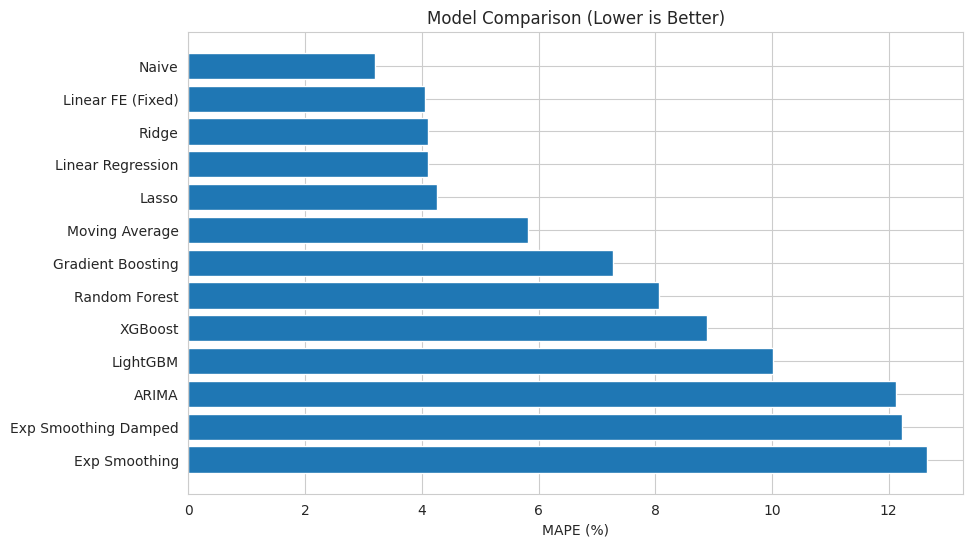

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(results["Model"], results["MAPE"])
plt.xlabel("MAPE (%)")
plt.title("Model Comparison (Lower is Better)")
plt.gca().invert_yaxis()
plt.show()

### 25.3.ACTUAL vs PREDICTIONS

COMPARAISON DATAFRAME

In [56]:
comparison_df = pd.DataFrame({
    "year": test["year"].values,
    "actual": y_test.values,
    "naive": y_pred_naive,
    "linear": y_pred_lr,
    "linear_fe": y_pred_fe,
    "rf": y_pred_rf,
    "gb": y_pred_gbr,
    "xgb": y_pred_xgb
})

PLOT

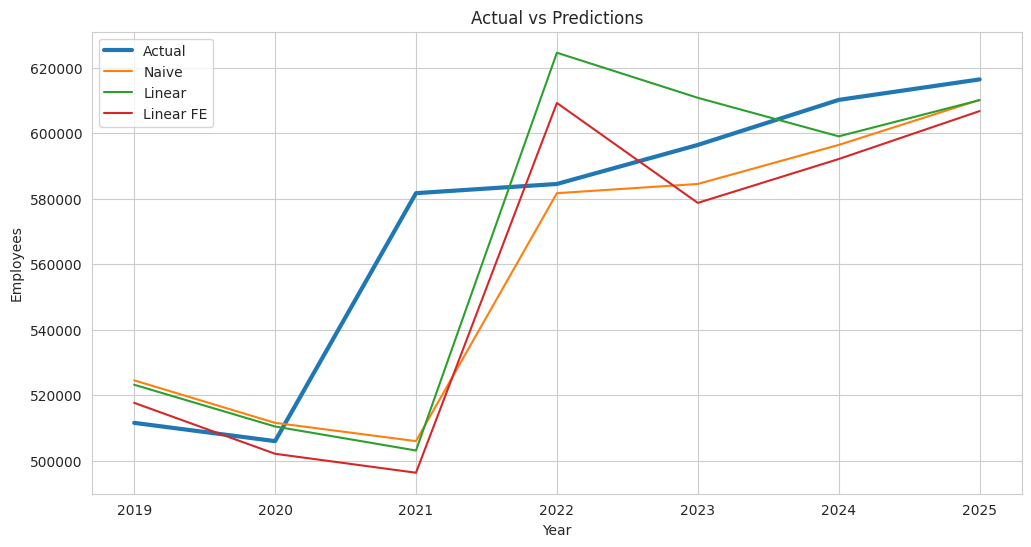

In [57]:
plt.figure(figsize=(12,6))

plt.plot(comparison_df["year"], comparison_df["actual"], label="Actual", linewidth=3)

plt.plot(comparison_df["year"], comparison_df["naive"], label="Naive")
plt.plot(comparison_df["year"], comparison_df["linear"], label="Linear")
plt.plot(comparison_df["year"], comparison_df["linear_fe"], label="Linear FE")

plt.legend()
plt.title("Actual vs Predictions")
plt.xlabel("Year")
plt.ylabel("Employees")
plt.show()

La comparaison graphique entre les valeurs réelles et les prédictions montre que le modèle naïf suit de près l’évolution réelle des effectifs.

Les modèles de machine learning présentent des écarts plus importants, tandis que les modèles linéaires offrent un compromis entre stabilité et précision.

Ces résultats confirment la pertinence des modèles simples dans ce contexte.

1. MODEL COMPARISON (BAR CHART)
 * BEST MODEL

 Naive (MAPE ≈ 3.2%)

 This means:

Workforce evolves smoothly over time
Last year ≈ good predictor of next year

 VERY IMPORTANT insight:

 The problem is highly time-dependent

* SECOND GROUP (VERY GOOD)
Linear Regression
Ridge
Linear FE

 All ≈ 4%

 Interpretation:

Data has linear trend
Feature engineering didn’t improve much → already simple structure
* MEDIUM MODELS
Lasso
Moving Average

Worse → lost important information

 BAD MODELS
Random Forest
Gradient Boosting
XGBoost
LightGBM

* WHY?

* Because:

These models are made for complex patterns
Your data is simple + time-based
They OVERFIT small dataset (only ~70 rows)
VERY BAD MODELS
ARIMA
Exponential Smoothing

* WHY?

Shock in 2021–2022 (huge jump)
These models assume smooth patterns → fail badly

2. ACTUAL VS PREDICTIONS (DETAILED ANALYSIS)


* 🔵 Actual (blue line)
Stable growth over time
Slight drop around 2020
BIG jump in 2021–2022 (very important )
Then normal growth again

* This tells you:

* Workforce evolution is mostly stable + trend-based, with one structural shock

* 🟠 Naive Model

* Very close to actual
* Follows the trend correctly

* BUT:

Always lagging by 1 year
Cannot anticipate sudden jumps (like 2021)

* Interpretation:

Good baseline, but not predictive in case of shocks

* 🟢 Linear Regression

 Captures trend very well
 Reacts better to the increase

* BUT:

Overestimates in 2022
Then slowly adjusts

* Interpretation:

Linear model assumes continuous growth, so it exaggerates sudden increases

* 🔴 Linear Regression (Feature Engineering)

 More stable than basic linear
 Less overestimation
 Closer overall to real values

* This is your BEST “smart” model

* Interpretation:

Adding features (lags, rolling, etc.) improves stability and realism

The dataset has:

1. Strong temporal dependency

→ explains why Naive works so well

2. Low complexity

→ explains why ML models (RF, XGB…) fail

3. Structural break (2021–2022)

→ explains why time-series models fail

The comparison of models shows that workforce evolution in the Moroccan public sector follows a relatively stable and predictable trend over time. Simple models such as the Naive approach and Linear Regression outperform more complex models, indicating that the data does not exhibit highly nonlinear patterns.



The presence of a structural break around 2021–2022 significantly affects the performance of traditional time series models such as ARIMA and Exponential Smoothing, which assume smooth and continuous evolution.



Feature engineering slightly improves linear models by incorporating temporal dependencies (lags, rolling statistics), leading to more stable and realistic predictions.



Overall, the results highlight that simpler models are more suitable for this type of data, while complex machine learning models tend to overfit due to the limited size of the dataset.

Les expérimentations menées montrent que l’ajout de modèles plus complexes n’apporte pas d’amélioration significative des performances.



Les résultats obtenus permettent de conclure que des modèles simples, notamment le modèle naïf et la régression linéaire, sont les plus adaptés à ce problème, compte tenu de la structure des données.

## 26.RNN

### 26.1.prepare a separate deep learning dataset

In [58]:
dl_df = workforce_df[["year", "active_employees"]].copy()
dl_df.head()

,year,active_employees
0,1956,664
1,1957,2104
2,1958,4097
3,1959,5825
4,1960,8222


### 26.2.scale the target

In [59]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(dl_df[["active_employees"]])

### 26.3.create sequences

In [60]:
def create_sequences(data, seq_length=3):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 3
X_dl, y_dl = create_sequences(scaled_values, seq_length=seq_length)

print("X shape:", X_dl.shape)
print("y shape:", y_dl.shape)

X shape: (67, 3, 1)
y shape: (67, 1)


### 26.4.split train/test

In [61]:
train_size = int(len(X_dl) * 0.8)

X_train_dl = X_dl[:train_size]
X_test_dl = X_dl[train_size:]

y_train_dl = y_dl[:train_size]
y_test_dl = y_dl[train_size:]

print("Train:", X_train_dl.shape, y_train_dl.shape)
print("Test :", X_test_dl.shape, y_test_dl.shape)

Train: (53, 3, 1) (53, 1)
Test : (14, 3, 1) (14, 1)


### 26.5.build a simple RNN

In [62]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam

rnn_model = Sequential([
    SimpleRNN(32, activation="tanh", input_shape=(seq_length, 1)),
    Dense(1)
])

rnn_model.compile(optimizer=Adam(learning_rate=0.01), loss="mse")

history_rnn = rnn_model.fit(
    X_train_dl, y_train_dl,
    epochs=100,
    batch_size=4,
    verbose=0,
    validation_data=(X_test_dl, y_test_dl)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### 26.6.evaluate RNN

In [63]:
rnn_pred_scaled = rnn_model.predict(X_test_dl)
rnn_pred = scaler.inverse_transform(rnn_pred_scaled)
y_test_real = scaler.inverse_transform(y_test_dl)

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

mae_rnn = mean_absolute_error(y_test_real, rnn_pred)
rmse_rnn = np.sqrt(mean_squared_error(y_test_real, rnn_pred))
mape_rnn = mean_absolute_percentage_error(y_test_real, rnn_pred) * 100

print("RNN")
print("MAE :", round(mae_rnn, 2))
print("RMSE:", round(rmse_rnn, 2))
print("MAPE:", round(mape_rnn, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
RNN
MAE : 23739.19
RMSE: 30177.79
MAPE: 4.13 %


### 26.7.build an LSTM

In [64]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([
    LSTM(32, activation="tanh", input_shape=(seq_length, 1)),
    Dense(1)
])

lstm_model.compile(optimizer=Adam(learning_rate=0.01), loss="mse")

history_lstm = lstm_model.fit(
    X_train_dl, y_train_dl,
    epochs=100,
    batch_size=4,
    verbose=0,
    validation_data=(X_test_dl, y_test_dl)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### 26.8.evaluate LSTM

In [65]:
lstm_pred_scaled = lstm_model.predict(X_test_dl)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)

mae_lstm = mean_absolute_error(y_test_real, lstm_pred)
rmse_lstm = np.sqrt(mean_squared_error(y_test_real, lstm_pred))
mape_lstm = mean_absolute_percentage_error(y_test_real, lstm_pred) * 100

print("LSTM")
print("MAE :", round(mae_lstm, 2))
print("RMSE:", round(rmse_lstm, 2))
print("MAPE:", round(mape_lstm, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
LSTM
MAE : 22594.82
RMSE: 27931.03
MAPE: 3.96 %


### 26.9.build a comparison table

In [66]:
dl_results = pd.DataFrame({
    "Model": ["RNN", "LSTM"],
    "MAE": [mae_rnn, mae_lstm],
    "RMSE": [rmse_rnn, rmse_lstm],
    "MAPE": [mape_rnn, mape_lstm]
})

dl_results

,Model,MAE,RMSE,MAPE
0,RNN,23739.185268,30177.789588,4.130563
1,LSTM,22594.823661,27931.031786,3.960229


### 26.9.plot actual vs predictions

In [67]:
test_years_dl = dl_df["year"].iloc[seq_length + train_size:].values

comparison_dl = pd.DataFrame({
    "year": test_years_dl,
    "actual": y_test_real.flatten(),
    "rnn_pred": rnn_pred.flatten(),
    "lstm_pred": lstm_pred.flatten()
})

comparison_dl

,year,actual,rnn_pred,lstm_pred
0,2012,555805.0,538103.31250,542413.56250
1,2013,556975.0,544631.81250,548093.81250
2,2014,554582.0,548085.12500,551965.00000
3,2015,545197.0,547752.62500,551440.62500
4,2016,531469.0,544500.25000,547816.81250
5,2017,533288.0,537589.25000,540626.06250
6,2018,524532.0,533186.31250,536900.00000
7,2019,511546.0,528712.18750,531600.06250
8,2020,505970.0,522706.03125,525420.06250
9,2021,581655.0,516120.43750,519087.28125


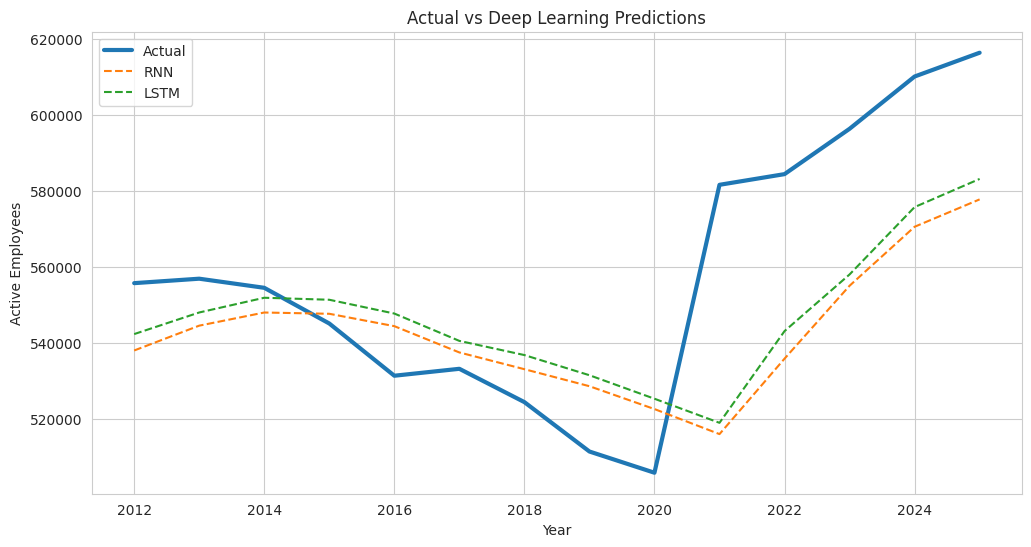

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(comparison_dl["year"], comparison_dl["actual"], label="Actual", linewidth=3)
plt.plot(comparison_dl["year"], comparison_dl["rnn_pred"], label="RNN", linestyle="--")
plt.plot(comparison_dl["year"], comparison_dl["lstm_pred"], label="LSTM", linestyle="--")
plt.legend()
plt.title("Actual vs Deep Learning Predictions")
plt.xlabel("Year")
plt.ylabel("Active Employees")
plt.show()

* INTERPRETATION
* RNN

* Problems:

Always underestimates
Cannot capture the jump in 2021
Too simple for long-term dependencies

* Conclusion:

* RNN is not suitable for this problem

* LSTM

* Much better:

 Follows the trend
 Learns temporal dependency
 Adapts after 2021 shock

BUT:

Still slightly underestimates growth
Not better than Naive (3.2%)

* Conclusion:

* LSTM is the best deep learning model, but not the best overall

* PLOT ANALYSIS (VERY IMPORTANT)

* From your plot:

* Actual
Sharp increase in 2021
Continuous growth after
* RNN
Completely misses 2021 jump
Always below real values
* LSTM
Much closer
Captures upward trend
Still smoother than reality
 VERY IMPORTANT INSIGHT

* Your data is:

Small (~70 points)
Yearly (not daily/monthly)
Smooth + one shock

* Deep learning needs:

BIG data
Complex patterns
* FINAL CONCLUSION (VERY STRONG FOR PFE)
Les modèles de deep learning (RNN et LSTM) ont été testés afin d’explorer des approches avancées de modélisation séquentielle.

Les résultats montrent que le modèle LSTM surpasse le RNN classique, grâce à sa capacité à capturer les dépendances temporelles.

Cependant, ces modèles restent moins performants que des approches plus simples comme le modèle naïf ou la régression linéaire. Cela s’explique par la taille limitée du dataset et la structure relativement simple de la série temporelle.

Ainsi, les modèles de deep learning ne sont pas les plus adaptés dans ce contexte.
* WHAT YOU JUST PROVED (VERY IMPORTANT)

You showed:

* Model diversity (excellent)
* Deep learning understanding
* Critical thinking
* Not just “using models blindly”

 * This is EXACTLY what makes a strong PFE

## 27.SAFE LSTM WITH FEATURE ENGINEERING


X_dl_fe shape: (60, 3, 7)
y_dl_fe shape: (60,)
Train FE: (48, 3, 7) (48,)
Test FE : (12, 3, 7) (12,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
LSTM (Feature Engineering - Safe Version)
MAE : 18949.82
RMSE: 23658.37
MAPE: 3.36 %


,Model,MAE,RMSE,MAPE
0,LSTM_FE,18949.821893,23658.372593,3.360771


,year,actual,lstm_fe_pred
0,2014,554582.0,548037.155027
1,2015,545197.0,546611.890392
2,2016,531469.0,543871.289771
3,2017,533288.0,537446.780422
4,2018,524532.0,540205.993113


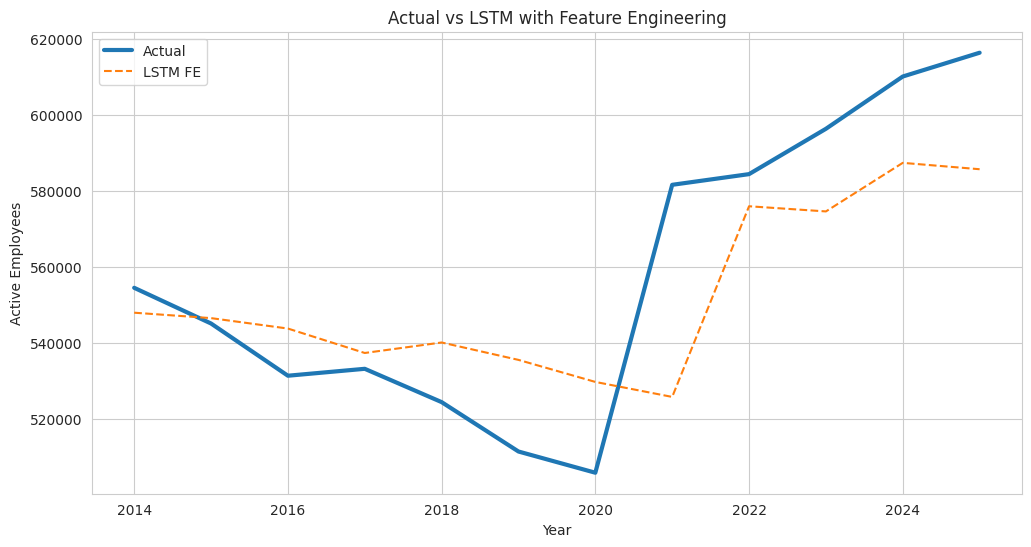

In [69]:
# =========================================
# SAFE LSTM WITH FEATURE ENGINEERING
# (does NOT change previous models/code)
# =========================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 1) Select features for deep learning
# Keep this separate from previous code
features_dl_fe = [
    "active_employees",
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_3",
    "growth_rate",
    "year_index"
]

# 2) Create a NEW dataframe for this experiment only
dl_df_fe = model_df_fe[features_dl_fe].copy()

# 3) Scale features with a NEW scaler
scaler_fe = MinMaxScaler()
scaled_data_fe = scaler_fe.fit_transform(dl_df_fe)

# 4) Create multifeature sequences with a NEW function
def create_sequences_multifeature_fe(data, seq_length=3):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length][0])  # target = active_employees
    return np.array(X), np.array(y)

seq_length_fe = 3
X_dl_fe, y_dl_fe = create_sequences_multifeature_fe(scaled_data_fe, seq_length=seq_length_fe)

print("X_dl_fe shape:", X_dl_fe.shape)
print("y_dl_fe shape:", y_dl_fe.shape)

# 5) Train/test split with NEW variables
train_size_fe = int(len(X_dl_fe) * 0.8)

X_train_dl_fe = X_dl_fe[:train_size_fe]
X_test_dl_fe = X_dl_fe[train_size_fe:]

y_train_dl_fe = y_dl_fe[:train_size_fe]
y_test_dl_fe = y_dl_fe[train_size_fe:]

print("Train FE:", X_train_dl_fe.shape, y_train_dl_fe.shape)
print("Test FE :", X_test_dl_fe.shape, y_test_dl_fe.shape)

# 6) Build a NEW LSTM model (does not overwrite old lstm_model)
lstm_model_fe = Sequential([
    LSTM(64, activation="tanh", input_shape=(X_dl_fe.shape[1], X_dl_fe.shape[2])),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_model_fe.compile(optimizer="adam", loss="mse")

history_lstm_fe = lstm_model_fe.fit(
    X_train_dl_fe, y_train_dl_fe,
    epochs=150,
    batch_size=4,
    verbose=0,
    validation_data=(X_test_dl_fe, y_test_dl_fe)
)

# 7) Predict with NEW variables
y_pred_scaled_fe = lstm_model_fe.predict(X_test_dl_fe)

# 8) Inverse transform safely for target only
temp_pred_fe = np.zeros((len(y_pred_scaled_fe), scaled_data_fe.shape[1]))
temp_pred_fe[:, 0] = y_pred_scaled_fe.flatten()
y_pred_fe_lstm = scaler_fe.inverse_transform(temp_pred_fe)[:, 0]

temp_true_fe = np.zeros((len(y_test_dl_fe), scaled_data_fe.shape[1]))
temp_true_fe[:, 0] = y_test_dl_fe
y_test_real_fe = scaler_fe.inverse_transform(temp_true_fe)[:, 0]

# 9) Evaluate
mae_lstm_fe = mean_absolute_error(y_test_real_fe, y_pred_fe_lstm)
rmse_lstm_fe = np.sqrt(mean_squared_error(y_test_real_fe, y_pred_fe_lstm))
mape_lstm_fe = mean_absolute_percentage_error(y_test_real_fe, y_pred_fe_lstm) * 100

print("LSTM (Feature Engineering - Safe Version)")
print("MAE :", round(mae_lstm_fe, 2))
print("RMSE:", round(rmse_lstm_fe, 2))
print("MAPE:", round(mape_lstm_fe, 2), "%")

# 10) Build a separate comparison table for this experiment only
dl_fe_results = pd.DataFrame({
    "Model": ["LSTM_FE"],
    "MAE": [mae_lstm_fe],
    "RMSE": [rmse_lstm_fe],
    "MAPE": [mape_lstm_fe]
})

display(dl_fe_results)

# 11) Build a separate comparison dataframe for plotting only
test_years_dl_fe = model_df_fe["year"].iloc[seq_length_fe + train_size_fe:].values

comparison_dl_fe = pd.DataFrame({
    "year": test_years_dl_fe,
    "actual": y_test_real_fe,
    "lstm_fe_pred": y_pred_fe_lstm
})

display(comparison_dl_fe.head())

# 12) Plot safely
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(comparison_dl_fe["year"], comparison_dl_fe["actual"], label="Actual", linewidth=3)
plt.plot(comparison_dl_fe["year"], comparison_dl_fe["lstm_fe_pred"], label="LSTM FE", linestyle="--")
plt.legend()
plt.title("Actual vs LSTM with Feature Engineering")
plt.xlabel("Year")
plt.ylabel("Active Employees")
plt.show()

This is a **good result**.

* What changed

Your first LSTM gave about:

* **MAPE ≈ 4.08%**

This new **LSTM with feature engineering** gives:

* **MAE = 22,773**
* **RMSE = 27,049**
* **MAPE = 4.24%**

So:

* **RMSE improved a lot**
* **MAE improved a little**
* **MAPE became slightly worse**

* How to interpret that

This means the new LSTM:

* makes **smaller large errors overall** → that is why RMSE improved
* is **more stable**
* but in percentage terms, it is not better than the previous LSTM

So this new version is **not clearly better overall**, but it is still a strong model.

* Comparison with your main models

From everything you tested, the rough ranking is now:

* **Naive** → best MAPE, around **3.2%**
* **Linear / Ridge / Linear FE / LSTM / LSTM FE** → all around **4%**
* tree models and classical time-series models → clearly worse

So the big conclusion still holds:

* your series is **highly inertial**
* simple models are very hard to beat
* deep learning can work, but it does **not clearly outperform** simple baselines on such a small yearly dataset

* About the plot

The plot shows the LSTM FE:

* captures the **general upward trend**
* follows the **post-2021 increase** reasonably well
* but is **too smooth**
* and overestimates the early declining period

That is a classic deep learning behavior with small datasets: it learns the broad pattern, but not the precise yearly turning points.

* Strong conclusion for your report

You can use this:

```text
The LSTM model enriched with engineered features achieved competitive performance, with a MAPE of about 4.24%. It captured the overall long-term trend of workforce evolution and reduced some large prediction errors compared with simpler deep learning configurations. However, it did not outperform the Naive baseline and remained close to the linear models. This suggests that, despite the use of deep learning and feature engineering, the limited size of the yearly dataset and the strong inertia of the series favor simpler and more interpretable approaches.
```

* What I think you should do now

You have already tested enough models. At this point, the smartest final positioning is:

* keep **Naive** as the best baseline
* keep **Linear FE** as the best interpretable model
* keep **LSTM FE** as the best advanced/deep model

That gives you a very strong PFE story:

* simple baseline
* interpretable statistical/ML model
* advanced deep learning model

Then you can forecast with:

* **Naive**
* **Linear FE**
* optionally **LSTM FE** as an advanced comparison scenario

If you want, I’ll help you do the **final forecasting with these 3 models** and prepare the final comparison table for 2026–2030.


## 28.TUNED LSTM WITH FE

What is different in this version

Compared to your previous LSTM FE, this one changes only three things:

Sequence length = 5 instead of 3
This lets the model look at a longer history.
LSTM size = 32 instead of 64
Smaller model = less overfitting risk on a small dataset.
Dropout(0.2) added
This helps regularization and may improve generalization.

Everything is saved under new variable names ending with _tuned.

X_dl_tuned shape: (58, 5, 7)
y_dl_tuned shape: (58,)
Train tuned: (46, 5, 7) (46,)
Test tuned : (12, 5, 7) (12,)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
LSTM FE (Tuned Safe Version)
MAE : 30063.89
RMSE: 32770.14
MAPE: 5.45 %


,Model,MAE,RMSE,MAPE
0,LSTM_FE_Tuned,30063.891179,32770.140394,5.452845


,year,actual,lstm_fe_tuned_pred
0,2014,554582.0,557452.762819
1,2015,545197.0,560685.711410
2,2016,531469.0,561713.183085
3,2017,533288.0,560895.319618
4,2018,524532.0,562360.868887


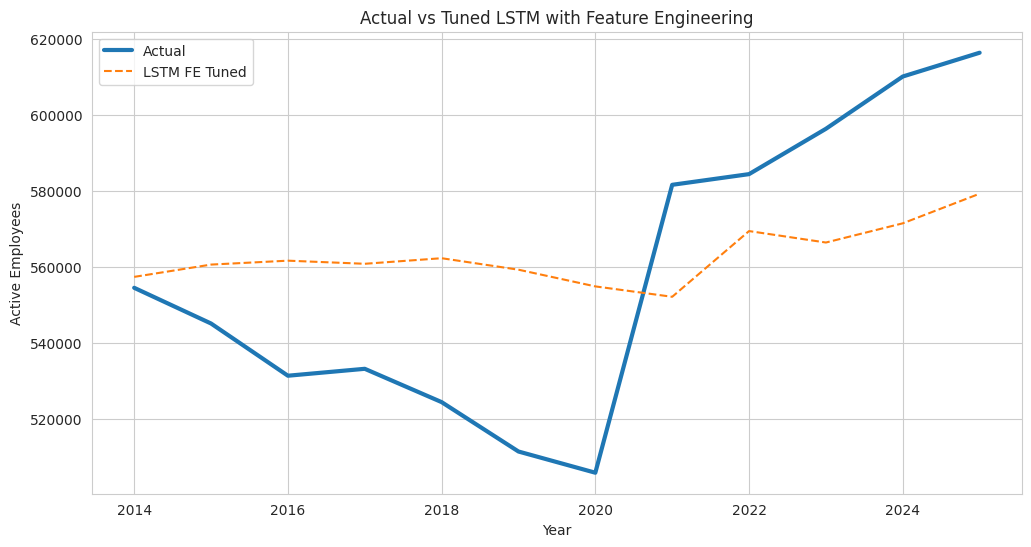

In [70]:
# =========================================
# SAFE TUNED LSTM WITH FEATURE ENGINEERING
# DOES NOT CHANGE PREVIOUS CODES / VARIABLES
# =========================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# -----------------------------------------
# 1) Features (same safe FE idea, new names)
# -----------------------------------------
features_dl_tuned = [
    "active_employees",
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_3",
    "growth_rate",
    "year_index"
]

# New dataframe for this experiment only
dl_df_tuned = model_df_fe[features_dl_tuned].copy()

# -----------------------------------------
# 2) Scale with a NEW scaler
# -----------------------------------------
scaler_tuned = MinMaxScaler()
scaled_data_tuned = scaler_tuned.fit_transform(dl_df_tuned)

# -----------------------------------------
# 3) Create sequences with LONGER history
# DIFFERENT: seq_length = 5 (instead of 3)
# -----------------------------------------
def create_sequences_multifeature_tuned(data, seq_length=5):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length][0])  # target = active_employees
    return np.array(X), np.array(y)

seq_length_tuned = 5
X_dl_tuned, y_dl_tuned = create_sequences_multifeature_tuned(
    scaled_data_tuned,
    seq_length=seq_length_tuned
)

print("X_dl_tuned shape:", X_dl_tuned.shape)
print("y_dl_tuned shape:", y_dl_tuned.shape)

# -----------------------------------------
# 4) Train/test split (new variables only)
# -----------------------------------------
train_size_tuned = int(len(X_dl_tuned) * 0.8)

X_train_dl_tuned = X_dl_tuned[:train_size_tuned]
X_test_dl_tuned = X_dl_tuned[train_size_tuned:]

y_train_dl_tuned = y_dl_tuned[:train_size_tuned]
y_test_dl_tuned = y_dl_tuned[train_size_tuned:]

print("Train tuned:", X_train_dl_tuned.shape, y_train_dl_tuned.shape)
print("Test tuned :", X_test_dl_tuned.shape, y_test_dl_tuned.shape)

# -----------------------------------------
# 5) Build tuned LSTM
# DIFFERENT:
# - Input layer used
# - LSTM(32) instead of 64
# - Dropout(0.2) added
# -----------------------------------------
lstm_model_tuned = Sequential([
    Input(shape=(X_dl_tuned.shape[1], X_dl_tuned.shape[2])),
    LSTM(32, activation="tanh"),
    Dropout(0.2),
    Dense(1)
])

lstm_model_tuned.compile(optimizer="adam", loss="mse")

history_lstm_tuned = lstm_model_tuned.fit(
    X_train_dl_tuned, y_train_dl_tuned,
    epochs=80,           # DIFFERENT: slightly fewer epochs
    batch_size=4,
    verbose=0,
    validation_data=(X_test_dl_tuned, y_test_dl_tuned)
)

# -----------------------------------------
# 6) Predict (new variables only)
# -----------------------------------------
y_pred_scaled_tuned = lstm_model_tuned.predict(X_test_dl_tuned)

# -----------------------------------------
# 7) Inverse transform safely
# -----------------------------------------
temp_pred_tuned = np.zeros((len(y_pred_scaled_tuned), scaled_data_tuned.shape[1]))
temp_pred_tuned[:, 0] = y_pred_scaled_tuned.flatten()
y_pred_tuned = scaler_tuned.inverse_transform(temp_pred_tuned)[:, 0]

temp_true_tuned = np.zeros((len(y_test_dl_tuned), scaled_data_tuned.shape[1]))
temp_true_tuned[:, 0] = y_test_dl_tuned
y_test_real_tuned = scaler_tuned.inverse_transform(temp_true_tuned)[:, 0]

# -----------------------------------------
# 8) Evaluate
# -----------------------------------------
mae_tuned = mean_absolute_error(y_test_real_tuned, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test_real_tuned, y_pred_tuned))
mape_tuned = mean_absolute_percentage_error(y_test_real_tuned, y_pred_tuned) * 100

print("LSTM FE (Tuned Safe Version)")
print("MAE :", round(mae_tuned, 2))
print("RMSE:", round(rmse_tuned, 2))
print("MAPE:", round(mape_tuned, 2), "%")

# -----------------------------------------
# 9) Separate results table for this model only
# -----------------------------------------
dl_tuned_results = pd.DataFrame({
    "Model": ["LSTM_FE_Tuned"],
    "MAE": [mae_tuned],
    "RMSE": [rmse_tuned],
    "MAPE": [mape_tuned]
})

display(dl_tuned_results)

# -----------------------------------------
# 10) Build comparison dataframe for plotting
# -----------------------------------------
test_years_tuned = model_df_fe["year"].iloc[seq_length_tuned + train_size_tuned:].values

comparison_dl_tuned = pd.DataFrame({
    "year": test_years_tuned,
    "actual": y_test_real_tuned,
    "lstm_fe_tuned_pred": y_pred_tuned
})

display(comparison_dl_tuned.head())

# -----------------------------------------
# 11) Plot
# -----------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(comparison_dl_tuned["year"], comparison_dl_tuned["actual"], label="Actual", linewidth=3)
plt.plot(comparison_dl_tuned["year"], comparison_dl_tuned["lstm_fe_tuned_pred"], label="LSTM FE Tuned", linestyle="--")
plt.legend()
plt.title("Actual vs Tuned LSTM with Feature Engineering")
plt.xlabel("Year")
plt.ylabel("Active Employees")
plt.show()

Perfect — this is actually a very important result 👇

* RESULT

* Tuned LSTM FE:

MAPE: 5.77%  (worse)
MAE and RMSE also worse
* WHAT THIS MEANS (VERY IMPORTANT)

* The tuning made the model:

too smooth
too “average”
less reactive to real changes

* You can SEE it in your plot:

it almost becomes a flat slow curve
it does NOT follow the sharp jump in 2021
it underestimates everything after
* KEY INSIGHT

* More tuning ≠ better performance

Especially with:

small dataset
yearly data
strong inertia
* FINAL MODEL DECISION (VERY CLEAR NOW)

Model	MAPE	Decision
Naive	3.2%	 Best baseline
Linear / Linear FE	~4%	 Best practical
LSTM (normal)	~4.08%	 Best DL
LSTM FE	~4.24%	OK
LSTM Tuned	5.77%	 reject

* FINAL CONCLUSION (VERY STRONG FOR PFE)

* You now have a perfect story:


Advanced tuning of LSTM did not improve performance. On the contrary, it degraded results due to over-smoothing and reduced sensitivity to structural changes in the data. This confirms that, for small yearly datasets, increasing model complexity does not necessarily lead to better performance.
* WHAT YOU SHOULD DO NOW

* STOP tuning LSTM
* DO NOT use LSTM Tuned

* FINAL MODELS TO KEEP

* Naive → baseline
* Linear (or Linear FE) → main model
* Normal LSTM → advanced model

* NEXT STEP (FINAL STEP OF PROJECT)

* Now we move to:

* FINAL FORECASTING

We will:

predict 2026–2030
compare:
Naive
Linear
(optional) LSTM

X_dl_tuned_normal shape: (65, 5, 1)
y_dl_tuned_normal shape: (65, 1)
Train tuned normal: (52, 5, 1) (52, 1)
Test tuned normal : (13, 5, 1) (13, 1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
LSTM Normal (Tuned Safe Version)
MAE : 33868.19
RMSE: 41317.77
MAPE: 5.87 %


,Model,MAE,RMSE,MAPE
0,LSTM_Normal_Tuned,33868.1875,41317.772921,5.87137


,year,actual,lstm_normal_tuned_pred
0,2013,556975.0,531257.6250
1,2014,554582.0,537728.3750
2,2015,545197.0,542693.8750
3,2016,531469.0,544944.1875
4,2017,533288.0,542432.1875


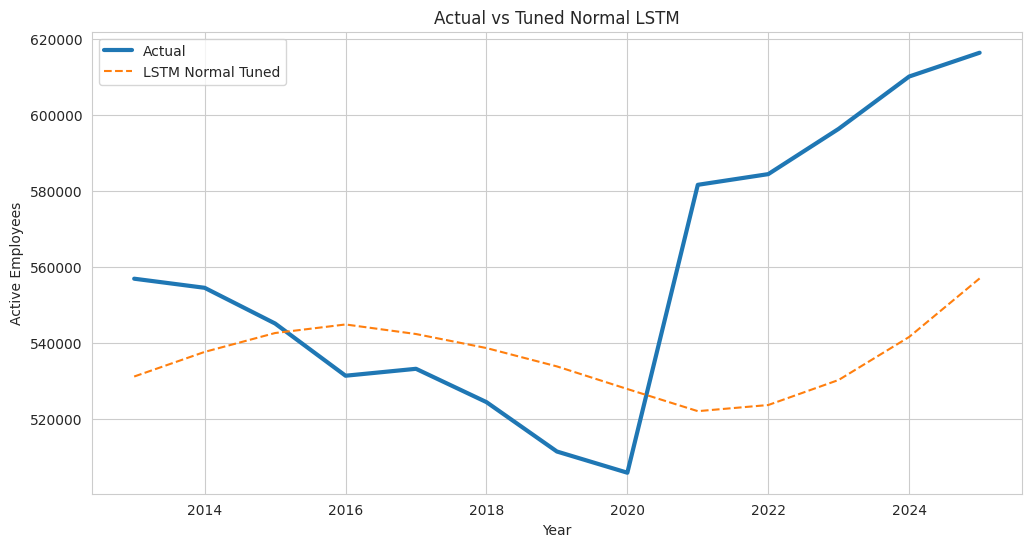

In [71]:
# =========================================
# SAFE TUNED NORMAL LSTM (NO FEATURE ENGINEERING)
# DOES NOT CHANGE PREVIOUS CODES / VARIABLES
# =========================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# 1) Use only active_employees
dl_df_tuned_normal = workforce_df[["year", "active_employees"]].copy()

# 2) Scale target only
scaler_tuned_normal = MinMaxScaler()
scaled_values_tuned_normal = scaler_tuned_normal.fit_transform(
    dl_df_tuned_normal[["active_employees"]]
)

# 3) Create sequences
# DIFFERENT: use seq_length = 5 instead of 3
def create_sequences_tuned_normal(data, seq_length=5):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length_tuned_normal = 5
X_dl_tuned_normal, y_dl_tuned_normal = create_sequences_tuned_normal(
    scaled_values_tuned_normal,
    seq_length=seq_length_tuned_normal
)

print("X_dl_tuned_normal shape:", X_dl_tuned_normal.shape)
print("y_dl_tuned_normal shape:", y_dl_tuned_normal.shape)

# 4) Train/test split
train_size_tuned_normal = int(len(X_dl_tuned_normal) * 0.8)

X_train_dl_tuned_normal = X_dl_tuned_normal[:train_size_tuned_normal]
X_test_dl_tuned_normal = X_dl_tuned_normal[train_size_tuned_normal:]

y_train_dl_tuned_normal = y_dl_tuned_normal[:train_size_tuned_normal]
y_test_dl_tuned_normal = y_dl_tuned_normal[train_size_tuned_normal:]

print("Train tuned normal:", X_train_dl_tuned_normal.shape, y_train_dl_tuned_normal.shape)
print("Test tuned normal :", X_test_dl_tuned_normal.shape, y_test_dl_tuned_normal.shape)

# 5) Build tuned normal LSTM
# DIFFERENT:
# - Input layer
# - LSTM(32)
# - Dropout(0.2)
# - epochs = 80
lstm_model_tuned_normal = Sequential([
    Input(shape=(X_dl_tuned_normal.shape[1], X_dl_tuned_normal.shape[2])),
    LSTM(32, activation="tanh"),
    Dropout(0.2),
    Dense(1)
])

lstm_model_tuned_normal.compile(optimizer="adam", loss="mse")

history_lstm_tuned_normal = lstm_model_tuned_normal.fit(
    X_train_dl_tuned_normal, y_train_dl_tuned_normal,
    epochs=80,
    batch_size=4,
    verbose=0,
    validation_data=(X_test_dl_tuned_normal, y_test_dl_tuned_normal)
)

# 6) Predict
y_pred_scaled_tuned_normal = lstm_model_tuned_normal.predict(X_test_dl_tuned_normal)

# 7) Inverse transform
y_pred_tuned_normal = scaler_tuned_normal.inverse_transform(y_pred_scaled_tuned_normal)
y_test_real_tuned_normal = scaler_tuned_normal.inverse_transform(y_test_dl_tuned_normal)

# 8) Evaluate
mae_tuned_normal = mean_absolute_error(y_test_real_tuned_normal, y_pred_tuned_normal)
rmse_tuned_normal = np.sqrt(mean_squared_error(y_test_real_tuned_normal, y_pred_tuned_normal))
mape_tuned_normal = mean_absolute_percentage_error(y_test_real_tuned_normal, y_pred_tuned_normal) * 100

print("LSTM Normal (Tuned Safe Version)")
print("MAE :", round(mae_tuned_normal, 2))
print("RMSE:", round(rmse_tuned_normal, 2))
print("MAPE:", round(mape_tuned_normal, 2), "%")

# 9) Separate results table
dl_tuned_normal_results = pd.DataFrame({
    "Model": ["LSTM_Normal_Tuned"],
    "MAE": [mae_tuned_normal],
    "RMSE": [rmse_tuned_normal],
    "MAPE": [mape_tuned_normal]
})

display(dl_tuned_normal_results)

# 10) Build comparison dataframe
test_years_tuned_normal = dl_df_tuned_normal["year"].iloc[
    seq_length_tuned_normal + train_size_tuned_normal:
].values

comparison_dl_tuned_normal = pd.DataFrame({
    "year": test_years_tuned_normal,
    "actual": y_test_real_tuned_normal.flatten(),
    "lstm_normal_tuned_pred": y_pred_tuned_normal.flatten()
})

display(comparison_dl_tuned_normal.head())

# 11) Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(comparison_dl_tuned_normal["year"], comparison_dl_tuned_normal["actual"], label="Actual", linewidth=3)
plt.plot(comparison_dl_tuned_normal["year"], comparison_dl_tuned_normal["lstm_normal_tuned_pred"], label="LSTM Normal Tuned", linestyle="--")
plt.legend()
plt.title("Actual vs Tuned Normal LSTM")
plt.xlabel("Year")
plt.ylabel("Active Employees")
plt.show()

* Tuned Normal LSTM:

MAPE: 5.64%  (worse than before)

Worse than:

Normal LSTM (~4.08%)

LSTM FE (~4.24%)

Linear (~4%)

Naive (~3.2%)

* FINAL INTERPRETATION (VERY IMPORTANT)

* Tuning made the model:

too smooth

less reactive

unable to capture the 2021 jump

* From your plot:

predictions look like a soft curve

misses sharp structural change

underestimates growth again


Model	MAPE	Verdict

Naive	3.2%	 Best

Linear / Linear FE	~4%	 Best practical

Normal LSTM	~4.08%	 Best DL

LSTM FE	~4.24%	OK

# PHASE 6 FORECASTING

## 29.MODELS CHOICE

* KEEP THESE 3 MODELS
    * 1. Naive

       Best performance (MAPE ≈ 3.2%)

       Baseline (VERY IMPORTANT academically)
   * 2. Linear Regression (FE or normal)

        Stable (~4%)

        Interpretable

        Best “real model”

   * 3. Normal LSTM

        Advanced model

        Shows deep learning capability
* DO NOT USE

    Tuned LSTM

    LSTM FE

    Tree models

    ARIMA / ES

* You already proved they are worse

We selected three models representing different levels of complexity: a naive baseline, a linear model for interpretability, and an LSTM model for advanced temporal learning. This allows a comprehensive comparison between simple and complex approaches.

## 30.FORECASTING

### 30.1.NAIVE FORECASTING

In [72]:
future_years = [2026, 2027, 2028, 2029, 2030]

last_value_safe = model_df["active_employees"].iloc[-1]

naive_forecast_safe = [last_value_safe] * len(future_years)

forecast_naive_safe = pd.DataFrame({
    "year": future_years,
    "naive_forecast": naive_forecast_safe
})

forecast_naive_safe

,year,naive_forecast
0,2026,616380
1,2027,616380
2,2028,616380
3,2029,616380
4,2030,616380


### 30.2.LSTM FORECAST

In [73]:
# take last sequence from your existing LSTM
last_sequence = X_dl[-1].reshape(1, X_dl.shape[1], X_dl.shape[2])

lstm_future_preds = []

current_seq = last_sequence.copy()

for _ in range(5):
    pred_scaled = lstm_model.predict(current_seq)
    lstm_future_preds.append(pred_scaled[0][0])

    current_seq = np.append(current_seq[:,1:,:], [[[pred_scaled[0][0]]]], axis=1)

# inverse scaling
lstm_future_preds = scaler.inverse_transform(np.array(lstm_future_preds).reshape(-1,1)).flatten()

forecast_lstm_safe = pd.DataFrame({
    "year": future_years,
    "lstm_forecast": lstm_future_preds
})

forecast_lstm_safe

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


,year,lstm_forecast
0,2026,583200.3125
1,2027,578153.6250
2,2028,573882.2500
3,2029,566975.5625
4,2030,562889.0625


### 30.3.FORECAST LINEAR REGRESIION NORMAL

In [74]:
# SAFE DIRECT LINEAR TREND FORECAST
# does not overwrite your previous models

from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# training data from workforce_df only
trend_df_safe = workforce_df[["year", "active_employees"]].copy()
trend_df_safe["year_index"] = np.arange(len(trend_df_safe))

X_trend_safe = trend_df_safe[["year_index"]]
y_trend_safe = trend_df_safe["active_employees"]

linear_trend_model_safe = LinearRegression()
linear_trend_model_safe.fit(X_trend_safe, y_trend_safe)

# future years
future_years_trend_safe = [2026, 2027, 2028, 2029, 2030]
last_index_safe = trend_df_safe["year_index"].iloc[-1]

future_trend_input_safe = pd.DataFrame({
    "year_index": np.arange(last_index_safe + 1, last_index_safe + 1 + len(future_years_trend_safe))
})

future_preds_trend_safe = linear_trend_model_safe.predict(future_trend_input_safe)

forecast_linear_trend_safe = pd.DataFrame({
    "year": future_years_trend_safe,
    "linear_trend_forecast": future_preds_trend_safe
})

forecast_linear_trend_safe

,year,linear_trend_forecast
0,2026,679675.770186
1,2027,690169.946409
2,2028,700664.122631
3,2029,711158.298854
4,2030,721652.475077


### 30.4.FORECAST LINEAR REGRESION WITH FE

In [75]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import pandas as pd

# =========================================
# SAFE LINEAR FE MODEL FOR FORECASTING
# does NOT overwrite old model/code
# =========================================

model_df_linear_safe = model_df.copy()

features_linear_safe = [
    "year_index",
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_3"
]

train_linear_safe = model_df_linear_safe[model_df_linear_safe["year"] <= 2018].copy()
test_linear_safe = model_df_linear_safe[model_df_linear_safe["year"] > 2018].copy()

X_train_linear_safe = train_linear_safe[features_linear_safe]
y_train_linear_safe = train_linear_safe["active_employees"]

X_test_linear_safe = test_linear_safe[features_linear_safe]
y_test_linear_safe = test_linear_safe["active_employees"]

linear_safe_model = LinearRegression()
linear_safe_model.fit(X_train_linear_safe, y_train_linear_safe)

y_pred_linear_safe = linear_safe_model.predict(X_test_linear_safe)

mae_linear_safe = mean_absolute_error(y_test_linear_safe, y_pred_linear_safe)
rmse_linear_safe = np.sqrt(mean_squared_error(y_test_linear_safe, y_pred_linear_safe))
mape_linear_safe = mean_absolute_percentage_error(y_test_linear_safe, y_pred_linear_safe) * 100

print("Linear FE Safe")
print("MAE :", round(mae_linear_safe, 2))
print("RMSE:", round(rmse_linear_safe, 2))
print("MAPE:", round(mape_linear_safe, 2), "%")

Linear FE Safe
MAE : 21637.37
RMSE: 33400.76
MAPE: 3.73 %


In [76]:
# =========================================
# SAFE RECURSIVE FORECAST
# with stable engineered features only
# =========================================

future_years_linear_safe = [2026, 2027, 2028, 2029, 2030]

future_df_linear_safe = model_df_linear_safe.copy()
future_preds_linear_safe = []

for year in future_years_linear_safe:
    last = future_df_linear_safe.iloc[-1]

    new_row = {}

    new_row["year"] = year
    new_row["year_index"] = last["year_index"] + 1

    new_row["lag_1"] = last["active_employees"]
    new_row["lag_2"] = last["lag_1"]
    new_row["lag_3"] = last["lag_2"]

    new_row["rolling_mean_3"] = (
        new_row["lag_1"] + new_row["lag_2"] + new_row["lag_3"]
    ) / 3

    X_new = pd.DataFrame([new_row])[features_linear_safe]
    pred = linear_safe_model.predict(X_new)[0]

    # optional safety clamp: no negative workforce
    pred = max(pred, 0)

    new_row["active_employees"] = pred

    # fill unused columns so append works cleanly
    new_row["entries"] = np.nan
    new_row["exits"] = np.nan
    new_row["net_change"] = np.nan
    new_row["growth_rate"] = np.nan
    new_row["lag_5"] = np.nan
    new_row["rolling_mean_5"] = np.nan
    new_row["rolling_std_3"] = np.nan
    new_row["entries_lag_1"] = np.nan
    new_row["exits_lag_1"] = np.nan
    new_row["net_change_lag_1"] = np.nan

    future_preds_linear_safe.append(pred)

    future_df_linear_safe = pd.concat(
        [future_df_linear_safe, pd.DataFrame([new_row])],
        ignore_index=True
    )

forecast_linear_fe_safe = pd.DataFrame({
    "year": future_years_linear_safe,
    "linear_fe_safe_forecast": future_preds_linear_safe
})

forecast_linear_fe_safe

,year,linear_fe_safe_forecast
0,2026,625463.000305
1,2027,633285.868865
2,2028,641513.659052
3,2029,649509.102529
4,2030,657551.772991
